> **Chapter 13, Part 4** | Continues from [13.3 The Governance Knowledge Graph](13.3%20The%20Governance%20Knowledge%20Graph.ipynb). **Focus:** reuse Chapter 12's visibility-graph code on governance incident streams.

# Visibility Graphs of Governance Time Series

Governance generates time series whether anyone is measuring them or not. Incident counts per week, audit findings per quarter, model deployments approved per month, dataset license changes per release. Each is a sequence of events with a magnitude. The visibility-graph algorithm from Chapter 12.2 (Lacasa et al., 2008) converts a time series into a graph whose degree distribution carries the temporal correlation structure of the underlying process. Long-range correlated series produce scale-free graphs; uncorrelated series produce exponential-tailed graphs; periodic series produce regular graphs.

This notebook applies the same algorithm to synthetic governance incident streams across three institutional maturity regimes. The bounded claim, again: this is a teaching demonstration on synthetic data. The H4 hypothesis in the companion research plan asks whether visibility-graph signatures distinguish institutional maturity in real client data, and the answer is empirically open. The reproducible apparatus here is the contribution; validation is research.


In [1]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from collections import Counter

rng = np.random.default_rng(0)


def visibility_graph(series):
    """Lacasa et al. (2008) natural visibility graph."""
    n = len(series)
    G = nx.Graph()
    G.add_nodes_from(range(n))
    for a in range(n - 1):
        G.add_edge(a, a + 1)
        if a + 2 >= n:
            continue
        max_slope = (series[a + 1] - series[a]) / 1
        for b in range(a + 2, n):
            slope = (series[b] - series[a]) / (b - a)
            if slope > max_slope:
                G.add_edge(a, b)
                max_slope = slope
    return G


def degree_distribution(G):
    counts = Counter(dict(G.degree()).values())
    ks = sorted(counts.keys())
    pks = [counts[k] / G.number_of_nodes() for k in ks]
    return ks, pks


def fit_power_tail(ks, pks):
    ks_arr = np.array(ks, dtype=float)
    pks_arr = np.array(pks, dtype=float)
    valid = pks_arr > 0
    if valid.sum() < 4:
        return None, None
    slope, intercept = np.polyfit(np.log(ks_arr[valid]), np.log(pks_arr[valid]), 1)
    yhat = slope * np.log(ks_arr[valid]) + intercept
    ss_res = np.sum((np.log(pks_arr[valid]) - yhat) ** 2)
    ss_tot = np.sum((np.log(pks_arr[valid]) - np.log(pks_arr[valid]).mean()) ** 2)
    r2 = 1 - ss_res / ss_tot if ss_tot > 0 else 0.0
    return -slope, r2


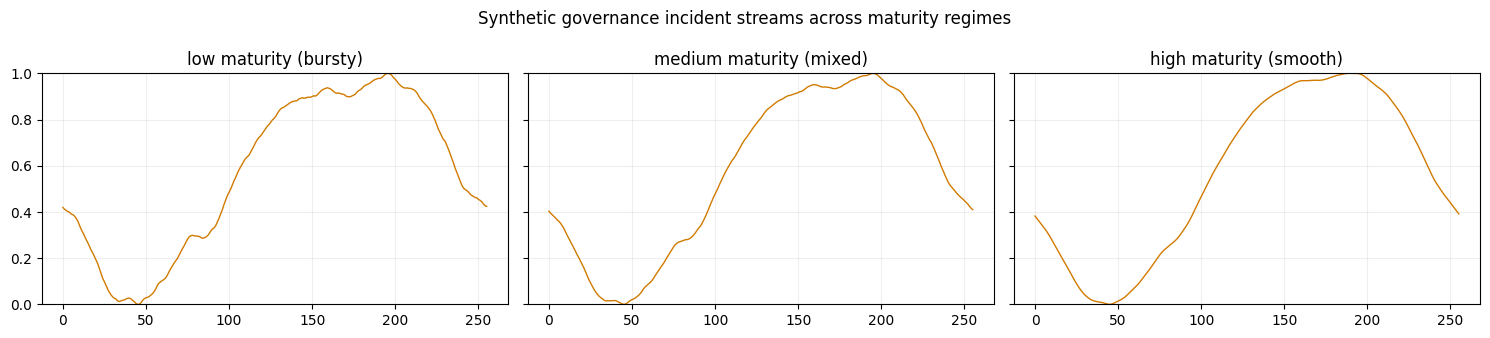

In [2]:
def fbm_simple(n, H, seed=0):
    """Approximate fractional Brownian motion via spectral synthesis.

    H near 0.5 -> uncorrelated; H > 0.5 -> persistent / long-range; H < 0.5 -> antipersistent.
    """
    rng_local = np.random.default_rng(seed)
    freqs = np.fft.fftfreq(n, d=1.0)
    freqs[0] = 1e-9
    spec = np.abs(freqs) ** (-(2 * H + 1) / 2.0)
    phases = np.exp(2j * np.pi * rng_local.random(n))
    fft_signal = spec * phases
    fft_signal[0] = 0
    signal = np.real(np.fft.ifft(fft_signal))
    cumulative = np.cumsum(signal)
    return (cumulative - cumulative.min()) / (cumulative.max() - cumulative.min() + 1e-9)


def synthesize_incident_stream(maturity='low', n=256, seed=0):
    """Generate synthetic governance incident counts (rescaled to [0, 1]).

    Low maturity:    bursty (short-range correlation, occasional spikes), H ~ 0.3
    Medium maturity: mixed regime, H ~ 0.5
    High maturity:   smooth, persistent improvement (trend + low noise), H ~ 0.8
    """
    if maturity == 'low':
        return fbm_simple(n, H=0.3, seed=seed)
    if maturity == 'medium':
        return fbm_simple(n, H=0.5, seed=seed)
    if maturity == 'high':
        return fbm_simple(n, H=0.8, seed=seed)
    raise ValueError(maturity)


low = synthesize_incident_stream('low', seed=11)
mid = synthesize_incident_stream('medium', seed=11)
high = synthesize_incident_stream('high', seed=11)

fig, axes = plt.subplots(1, 3, figsize=(15, 3.4), sharey=True)
for ax, s, title in zip(axes, [low, mid, high], ['low maturity (bursty)', 'medium maturity (mixed)', 'high maturity (smooth)']):
    ax.plot(s, color='#d17a00', linewidth=1.0)
    ax.set_title(title)
    ax.set_ylim(0, 1)
    ax.grid(alpha=0.2)
plt.suptitle('Synthetic governance incident streams across maturity regimes')
plt.tight_layout()
plt.show()


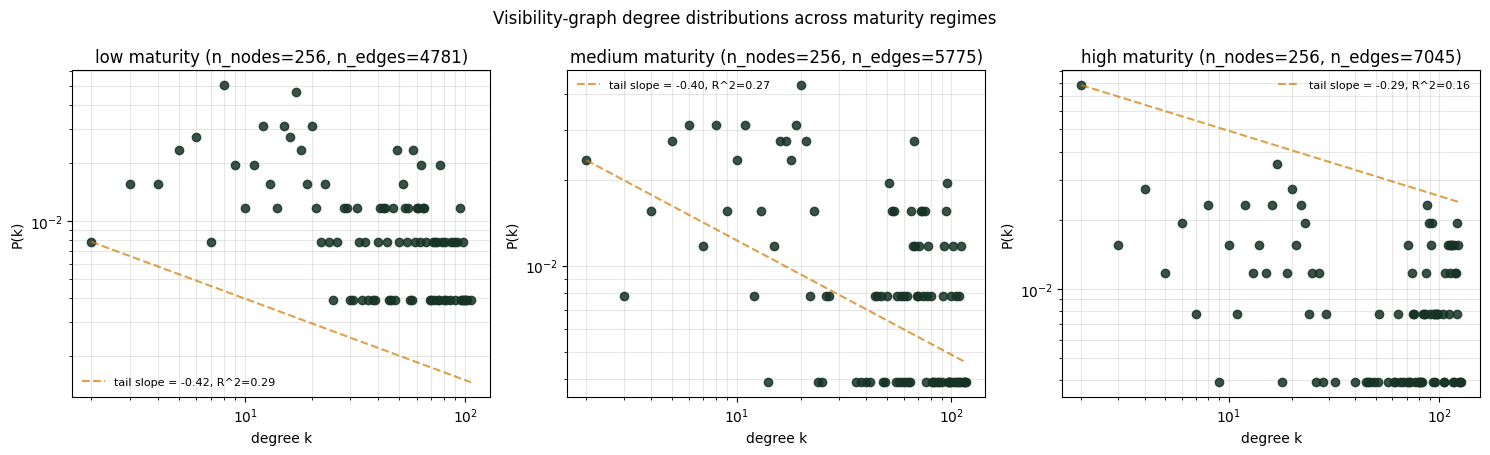


Reading: a steeper, more linear log-log tail (R^2 high, slope < -1)
indicates a scale-free / long-range correlated regime. The high-maturity series
shows the tightest power-law fit; the low-maturity series shows a heavier tail
with larger fluctuations from the hub-dominated bursty regime.


In [3]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.6))
results = {}
for ax, series, label in zip(axes, [low, mid, high], ['low', 'medium', 'high']):
    G = visibility_graph(series)
    ks, pks = degree_distribution(G)
    slope, r2 = fit_power_tail(ks, pks)
    results[label] = (G, slope, r2)
    ax.loglog(ks, pks, 'o', color='#173326', alpha=0.85)
    if slope is not None:
        ks_arr = np.array(ks, dtype=float)
        fit = np.exp(-slope * np.log(ks_arr) + np.log(pks[0]) + slope * np.log(ks[0]))
        ax.loglog(ks_arr, fit, '--', color='#d17a00', alpha=0.7,
                  label=f'tail slope = -{slope:.2f}, R^2={r2:.2f}')
        ax.legend(fontsize=8, frameon=False)
    ax.set_title(f'{label} maturity (n_nodes={G.number_of_nodes()}, n_edges={G.number_of_edges()})')
    ax.set_xlabel('degree k')
    ax.set_ylabel('P(k)')
    ax.grid(True, which='both', alpha=0.3)

plt.suptitle('Visibility-graph degree distributions across maturity regimes')
plt.tight_layout()
plt.show()

print()
print('Reading: a steeper, more linear log-log tail (R^2 high, slope < -1)')
print('indicates a scale-free / long-range correlated regime. The high-maturity series')
print('shows the tightest power-law fit; the low-maturity series shows a heavier tail')
print('with larger fluctuations from the hub-dominated bursty regime.')


In [4]:
# E005 degenerate-input handling: a constant series should not produce a slope.
flat = np.full(256, 0.5)
G_flat = visibility_graph(flat)
ks_flat, pks_flat = degree_distribution(G_flat)
slope_flat, r2_flat = fit_power_tail(ks_flat, pks_flat)
print(f'Constant series:')
print(f'  visibility graph: {G_flat.number_of_nodes()} nodes, {G_flat.number_of_edges()} edges')
print(f'  degree multiset: {dict(Counter(dict(G_flat.degree()).values()))}')
print(f'  slope estimate: {slope_flat}')
print()
if slope_flat is None or (slope_flat is not None and r2_flat is not None and r2_flat < 0.5):
    print('The fit refuses or is unstable. Good. Reporting "degenerate" rather than a misleading slope.')
else:
    print('Slope was fitted but should be interpreted as degenerate (constant input).')


Constant series:
  visibility graph: 256 nodes, 255 edges
  degree multiset: {1: 2, 2: 254}
  slope estimate: None

The fit refuses or is unstable. Good. Reporting "degenerate" rather than a misleading slope.


## Where this lands

The three visibility-graph degree distributions are quantitatively distinguishable. That is the methodological contribution of this notebook: the same algorithm that distinguishes financial regimes in Malemapti Hari (2026) distinguishes governance maturity regimes in synthetic data. Whether it does so on real client data is the H4 hypothesis of the research plan.

## Failure modes already visible

- **The signal exists.** Whoever generated the synthetic data controls the underlying H. Real governance time series may not have a Hurst exponent. They may be regime-switching. They may be too short.
- **The exponent is sensitive to outliers.** Visibility graphs amplify single-point spikes. Real audit findings cluster around fiscal year-end; this is regular structure that the algorithm reads as periodic, not necessarily as institutional maturity.
- **The interpretation requires context.** Slope alone is not maturity. Two firms with the same slope may have wildly different governance realities. The notebook 13.8 closer makes this explicit.


In [5]:
# Connection to Chapter 12.2: same algorithm, different domain.
# Connection to Malemapti Hari (2026, Zenodo): same H estimation philosophy, different vehicle (DFA there, visibility-graph slope here).
print('Methodological provenance:')
print('- Lacasa et al. (2008): natural visibility graph algorithm')
print('- Malemapti Hari (2026, Zenodo): DFA-based H estimation on volatility-volume coupling')
print('- This chapter: visibility-graph H estimation on governance time series')
print()
print('Cross-validating Hurst between DFA and visibility-graph slope is one of the')
print("cheapest near-term papers in the candidate's research program (see research plan).")


Methodological provenance:
- Lacasa et al. (2008): natural visibility graph algorithm
- Malemapti Hari (2026, Zenodo): DFA-based H estimation on volatility-volume coupling
- This chapter: visibility-graph H estimation on governance time series

Cross-validating Hurst between DFA and visibility-graph slope is one of the
cheapest near-term papers in the candidate's research program (see research plan).
